# Advanced Topics -- Heat Maps

## Importing relevant modules

We need to import `parcels` itself along with `matplotlib`, `xarray`, and `datetime`.

In [1]:
import xarray as xr
from xhistogram.xarray import histogram as xhist
import numpy as np

## Load data

Let's use the output from the drift kernel experiments.

In [2]:
ds = xr.open_zarr("MultipleSites2.zarr").compute()
ds = ds.isel(obs=slice(1, None))
ds

<xarray.Dataset> Size: 12MB
Dimensions:     (trajectory: 5000, obs: 119)
Coordinates:
  * obs         (obs) int32 476B 1 2 3 4 5 6 7 8 ... 113 114 115 116 117 118 119
  * trajectory  (trajectory) int64 40kB 5000 5001 5002 5003 ... 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 2MB -35.54 -35.55 ... -36.08 -36.07
    lon         (trajectory, obs) float32 2MB 19.97 19.97 19.97 ... 21.0 20.99
    time        (trajectory, obs) datetime64[ns] 5MB 2002-12-31T18:00:00 ... ...
    z           (trajectory, obs) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4CheckError
    parcels_mesh:           spherical
    parcels_version:        3.0.6

## Calculate time (obs) resolved histograms

Let's create 20 x 20 bins covering the whole particle cloud.

In [3]:
lon_bins = np.linspace(ds.lon.min().data[()], ds.lon.max().data[()], 41)
lat_bins = np.linspace(ds.lat.min().data[()], ds.lat.max().data[()], 41)

In [4]:
obs_counts = xhist(
    ds.lon, ds.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)

obs_counts

<xarray.DataArray 'histogram_lon_lat' (obs: 119, lon: 40, lat: 40)> Size: 2MB
array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
...
        ...,
        [  0,   0,   0, ...,   3,  38,  89],
        [  0,   0,   0, ...,   9,  11,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   1, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   4,   0, 130],
        [  0,   0,   0, ...,   3,  28,   5],
        [  0,   0,   0, ...,   0,   9,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   3,   0, 134],
        [  0,   0,   0, ...,   9,   0,  40],
        [  0,   0,   0, ...,   0,   8,  21]]])
Coordinates:
  * obs      (obs) int32 476B 1 2 3 4 5 6 7 8 ... 113 114 115 116 117 118 119
  * lon      (lon) float64 320B 19.71 19.89 20.07 20.25 ... 26.3 26.48 26.66
  * lat      (lat) float64 320B -38.14 -38.04 -37.93 ... -34.17 -34.07 -33.96

## Have a look

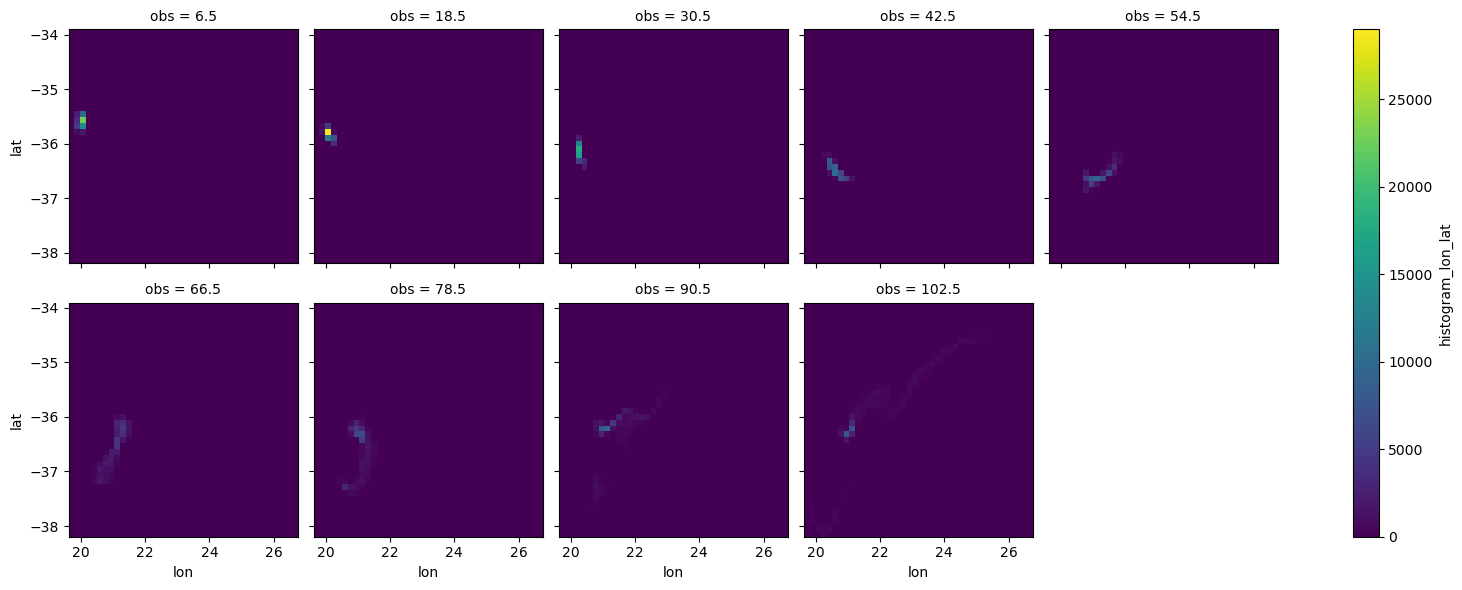

In [5]:
obs_counts.coarsen(obs=12, boundary="trim").sum().plot(x="lon", y="lat", col="obs", col_wrap=5)